# SP500 Five-Strategy Portfolio — v10
## Equal-vol weighting + sector neutralization

Strategies:
1. event_driven_v26      — volume shock z-score continuation
2. momentum_v29          — residual momentum, market-neutral L/S
3. resid_mr_v10          — residual mean reversion, proportional sizing
4. coint_mr_v28          — two-factor residual MR, beta-neutral
5. short_horizon_mom_w20 — 20d sector-relative momentum, L/S 20/20

In [5]:
from __future__ import annotations

import numpy as np
import pandas as pd

import qstudy as qs
from qstudy import PortfolioStudy, Study
from qstudy.constants import SECTOR_ETF_MAP, SECTOR_ETFS, SP500

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"

## Load Data

In [6]:
universe = qs.download(SP500, START_DATE, END_DATE)
benchmark = qs.download(["SPY"], START_DATE, END_DATE)
sector_factors = qs.download(["SPY", *SECTOR_ETFS], START_DATE, END_DATE)
sector_map = qs.get_sector_map(universe.tickers)

print(f"Universe: {len(universe.tickers)} tickers | {universe.returns.index[0].date()} - {universe.returns.index[-1].date()}")

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

1 Failed download:
['GEV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

1 Failed download:
['SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


Universe: 461 tickers | 2015-01-02 - 2023-12-29


## Strategy 1: Event-Driven Volume Shock (v26)

In [7]:
def build_event_driven_v26() -> Study:
    def volume_shock_zscore_signal(event_window=10, volume_window=30, volume_quantile=0.9,
                                   move_quantile=0.8, zscore_window=60):
        def signal_fn(**cache):
            returns = cache["_active_returns"]
            volume = cache["volume"]
            price_move = returns.rolling(event_window).sum()
            move_mean = price_move.rolling(zscore_window).mean()
            move_std = price_move.rolling(zscore_window).std().replace(0.0, np.nan)
            move_z = price_move.sub(move_mean).div(move_std)
            rel_vol = volume.div(volume.rolling(volume_window).mean().replace(0.0, np.nan))
            volume_shock = np.log(rel_vol.replace(0.0, np.nan))
            signal = move_z.mul(volume_shock)
            mask = rel_vol.ge(rel_vol.quantile(volume_quantile, axis=1), axis=0)
            mask &= move_z.abs().ge(move_z.abs().quantile(move_quantile, axis=1), axis=0)
            return signal.where(mask)
        signal_fn.__name__ = "volume_shock_zscore_signal"
        return signal_fn

    def demean(signal, **cache):
        return signal.sub(signal.mean(axis=1), axis=0)

    def delay_entry(days=1):
        def scaler(positions, **cache):
            return positions.shift(days).fillna(0.0)
        scaler.__name__ = f"delay_entry_{days}"
        return scaler

    return (
        Study(name="event_driven_v26", factors=sector_factors)
        .residualize_returns()
        .base_signal(volume_shock_zscore_signal(event_window=10, volume_window=30,
                                                volume_quantile=0.9, move_quantile=0.8,
                                                zscore_window=60))
        .transform_signal(demean)
        .add_vol_filter(vol_window=30, quantile=0.7, keep="low")
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=20, n_short=20)
        .weight_equal_vol(vol_window=60)
        .scale_risk(delay_entry(1))
        .rebalance(every=10)
    )

## Strategy 2: Residual Momentum (v29)

In [8]:
def build_momentum_v29() -> Study:
    def residual_momentum_signal(lookback=30, skip=20, shift=1):
        def signal_fn(**cache):
            return cache["residual_returns"].shift(skip).rolling(lookback).sum().shift(shift)
        signal_fn.__name__ = f"residual_momentum_signal_{lookback}_{skip}_{shift}"
        return signal_fn

    return (
        Study(name="momentum_v29", factors=sector_factors)
        .add_factor_model(factors=["market"])
        .residualize_returns()
        .base_signal(residual_momentum_signal(lookback=30, skip=20, shift=1))
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(20_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=20, n_short=20)
        .weight_equal()
        .neutralize_positions({"market": 0})
        .rebalance(every=10)
    )

## Strategy 3: Residual Mean Reversion (v10)

In [9]:
def build_resid_mr_v10() -> Study:
    def residual_mean_reversion_signal(**cache):
        return -cache["residual_returns"].rolling(5).mean().shift(1)

    def demean_signal(signal, **cache):
        return signal.sub(signal.mean(axis=1), axis=0)

    def proportional_positions(signal, **cache):
        z = signal.sub(signal.mean(axis=1), axis=0).div(signal.std(axis=1), axis=0).clip(-3, 3)
        z = z.sub(z.mean(axis=1), axis=0)
        gross = z.abs().sum(axis=1).replace(0.0, np.nan)
        return z.div(gross, axis=0)

    def equity_curve_regime_scale(positions, **cache):
        returns = cache["returns"]
        mask = cache.get("_tradeable_mask")
        if mask is None:
            mask = cache.get("_liquidity_mask")
        if mask is not None:
            returns = returns.where(mask)
        raw_ret = (positions.shift(1) * returns).sum(axis=1)
        equity = (1 + raw_ret).cumprod()
        scale = pd.Series(
            np.where(equity > equity.rolling(20).mean(), 1.0, 0.25), index=equity.index
        )
        return positions.mul(scale.shift(1), axis=0)

    def benchmark_regime_scale(positions, **cache):
        price = (1 + cache["benchmark"].fillna(0.0)).cumprod()
        scale = pd.Series(
            np.where(price.rolling(150).mean() >= price.rolling(250).mean(), 1.0, 0.75),
            index=price.index,
        )
        return positions.mul(scale.shift(1), axis=0)

    equity_curve_regime_scale.__name__ = "equity_curve_regime_scale"
    benchmark_regime_scale.__name__ = "benchmark_regime_scale"

    return (
        Study(name="resid_mr_v10", factors=sector_factors)
        .residualize_returns()
        .base_signal(residual_mean_reversion_signal)
        .transform_signal(demean_signal)
        .add_vol_filter(vol_window=5, quantile=0.6)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
        .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
        .build_positions(proportional_positions)
        .scale_risk(benchmark_regime_scale)
        .scale_risk(equity_curve_regime_scale)
        .rebalance(every=1)
    )

## Strategy 4: Two-Factor Residual MR (coint_mr v28)

In [10]:
def build_coint_mr_v28() -> Study:
    def _build_sector_returns_by_ticker(returns, sector_factors_data, sector_map_local):
        available = set(sector_factors_data.returns.columns)
        return pd.DataFrame(
            {
                ticker: sector_factors_data.returns[
                    SECTOR_ETF_MAP.get(sector_map_local.get(ticker, ""), "SPY")
                    if SECTOR_ETF_MAP.get(sector_map_local.get(ticker, ""), "SPY") in available
                    else "SPY"
                ]
                for ticker in returns.columns
            },
            index=sector_factors_data.returns.index,
        )

    def two_factor_residual_signal(beta_window=126, signal_window=8, clip=3.0):
        def signal_fn(**cache):
            returns = cache["returns"]
            bench = cache["benchmark"].reindex(returns.index).fillna(0.0)
            sector_ret_by_ticker = cache.get("_sector_returns_by_ticker")
            if sector_ret_by_ticker is None:
                bench_vals = bench.to_numpy()
                sector_ret_by_ticker = pd.DataFrame(
                    np.repeat(bench_vals[:, None], returns.shape[1], axis=1),
                    index=returns.index, columns=returns.columns,
                )
            market = pd.DataFrame(
                np.repeat(bench.to_numpy()[:, None], returns.shape[1], axis=1),
                index=returns.index, columns=returns.columns,
            )
            sector = sector_ret_by_ticker.reindex_like(returns).fillna(0.0)
            market_var = market.rolling(beta_window).var().replace(0.0, np.nan)
            stock_mkt_beta = returns.rolling(beta_window).cov(market).div(market_var)
            sector_mkt_beta = sector.rolling(beta_window).cov(market).div(market_var)
            stock_ex_mkt = returns - stock_mkt_beta.mul(market)
            sector_ex_mkt = sector - sector_mkt_beta.mul(market)
            sector_var = sector_ex_mkt.rolling(beta_window).var().replace(0.0, np.nan)
            sector_beta = stock_ex_mkt.rolling(beta_window).cov(sector_ex_mkt).div(sector_var)
            residual = (stock_ex_mkt - sector_beta.mul(sector_ex_mkt)).replace([np.inf, -np.inf], np.nan)
            signal_source = residual.rolling(signal_window).sum()
            z_mean = signal_source.rolling(signal_window).mean()
            z_std = signal_source.rolling(signal_window).std().replace(0.0, np.nan)
            return -(signal_source.sub(z_mean).div(z_std).clip(-clip, clip)).replace([np.inf, -np.inf], np.nan)
        signal_fn.__name__ = f"two_factor_residual_signal_{beta_window}_{signal_window}"
        return signal_fn

    def demean_signal(signal, **cache):
        return signal.sub(signal.mean(axis=1), axis=0)

    def sector_demean_signal(signal, **cache):
        sector_map_local = cache.get("_sector_map", {})
        adjusted = signal.copy()
        by_sector: dict[str, list[str]] = {}
        for ticker in adjusted.columns:
            by_sector.setdefault(sector_map_local.get(ticker, "Unknown"), []).append(ticker)
        for members in by_sector.values():
            cols = [t for t in members if t in adjusted.columns]
            if cols:
                adjusted.loc[:, cols] = adjusted[cols].sub(adjusted[cols].mean(axis=1), axis=0)
        return adjusted
    sector_demean_signal.__name__ = "sector_demean_signal"

    def beta_neutralize_positions(window=20):
        def scaler(positions, **cache):
            returns = cache["returns"]
            bench = cache["benchmark"].reindex(returns.index).fillna(0.0)
            mean_r = returns.rolling(window).mean()
            mean_b = bench.rolling(window).mean()
            cov = returns.mul(bench, axis=0).rolling(window).mean().sub(mean_r.mul(mean_b, axis=0))
            var_b = bench.rolling(window).var().replace(0.0, np.nan)
            betas = cov.div(var_b, axis=0).shift(1)
            adjusted = positions.copy()
            for date in positions.index:
                active = positions.loc[date]
                active = active[active != 0.0]
                if active.empty:
                    continue
                beta_slice = betas.loc[date, active.index].dropna()
                if len(beta_slice) < 2:
                    continue
                w = active.reindex(beta_slice.index)
                beta_exp = float((w * beta_slice).sum())
                beta_norm = float((beta_slice ** 2).sum())
                if beta_norm == 0.0:
                    continue
                neutralized = w - (beta_exp / beta_norm) * beta_slice
                gross = neutralized.abs().sum()
                if gross > 0.0 and not pd.isna(gross):
                    adjusted.loc[date, beta_slice.index] = neutralized / gross
            return adjusted.fillna(0.0)
        scaler.__name__ = f"beta_neutralize_positions_{window}"
        return scaler

    return (
        Study(name="coint_mr_v28", factors=sector_factors)
        .base_signal(two_factor_residual_signal(beta_window=126, signal_window=8))
        .transform_signal(demean_signal)
        .transform_signal(sector_demean_signal)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=10, n_short=10)
        .weight_equal_vol(vol_window=60)
        .scale_risk(beta_neutralize_positions(20))
        .rebalance(every=10)
    )

## Strategy 5: Short-Horizon Sector-Relative Momentum (w20_s0_equal)

In [30]:
def build_short_horizon_momentum_w20() -> Study:
    def short_horizon_sector_relative_signal(window=20, skip=0):
        def signal_fn(**cache):
            returns = cache["returns"]
            sector_map_s = pd.Series(sector_map).reindex(returns.columns).fillna("Unknown")
            stock_ret = returns.rolling(window).sum().shift(skip + 1)
            sector_ret = stock_ret.copy()
            for sector, tickers in sector_map_s.groupby(sector_map_s):
                cols = tickers.index.tolist()
                sector_ret.loc[:, cols] = stock_ret.loc[:, cols].mean(axis=1).values[:, None]
            return stock_ret - sector_ret
        signal_fn.__name__ = f"short_horizon_sector_relative_signal_{window}_{skip}"
        return signal_fn

    def sector_beta_neutralize_positions(window=60, passes=2):
        def scaler(positions, **cache):
            returns = cache["returns"]
            bench = cache["benchmark"].reindex(returns.index).fillna(0.0)
            mean_r = returns.rolling(window).mean()
            mean_b = bench.rolling(window).mean()
            cov = returns.mul(bench, axis=0).rolling(window).mean().sub(mean_r.mul(mean_b, axis=0))
            var_b = bench.rolling(window).var().replace(0.0, np.nan)
            betas = cov.div(var_b, axis=0).shift(1)
            adjusted = positions.copy()
            for date in positions.index:
                active = positions.loc[date]
                active = active[active != 0.0]
                if active.empty:
                    continue
                weights = active.copy()
                for _ in range(passes):
                    sectors = pd.Series({t: sector_map.get(t, "Unknown") for t in weights.index})
                    for s, tickers in sectors.groupby(sectors):
                        cols = tickers.index.tolist()
                        sw = weights.loc[cols]
                        weights.loc[cols] = sw - sw.mean()
                    beta_slice = betas.loc[date, weights.index].dropna()
                    if len(beta_slice) >= 2:
                        w = weights.reindex(beta_slice.index).fillna(0.0)
                        beta_exp = float((w * beta_slice).sum())
                        beta_norm = float((beta_slice ** 2).sum())
                        if beta_norm > 0.0:
                            weights.loc[beta_slice.index] = w - (beta_exp / beta_norm) * beta_slice
                weights = weights - weights.mean()
                gross = weights.abs().sum()
                if gross > 0.0 and not pd.isna(gross):
                    adjusted.loc[date, weights.index] = weights / gross
            return adjusted.fillna(0.0)
        scaler.__name__ = f"sector_beta_neutralize_positions_{window}_{passes}"
        return scaler

    return (
        Study(name="short_horizon_momentum_w20")
        .base_signal(short_horizon_sector_relative_signal(window=20, skip=0))
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(20_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=20, n_short=20)
        .weight_equal()
        .scale_risk(sector_beta_neutralize_positions(window=60, passes=2))
        .rebalance(every=10)
    )

## Build & Run Portfolio

In [37]:
strategies = [
    # build_event_driven_v26(),
    build_momentum_v29(),
    build_resid_mr_v10(),
    build_coint_mr_v28(),
    build_short_horizon_momentum_w20(),
]

portfolio = (
    PortfolioStudy(
        strategies=strategies,
        universe=universe,
        benchmark=benchmark,
        name="sp500_five_strat_port_v10_sector_neutral",
    )
    .weight_equal_vol(window=30)
    .neutralize_positions({"sector": 0}, sector_map=sector_map, beta_window=60)
    # .with_transaction_costs(5)
    .run()
)

momentum_v29:   8%|█████████▏                                                                                                              | 1/13 [00:00<00:00, 14.90it/s, stage=residualize]

Using barra-lite factor model for residuals...



resid_mr_v10:   0%|                                                                                                                                | 0/14 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...



sp500_five_strat_port_v10_sector_neutral: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:23<00:00,  2.64s/it, stage=metrics]


## Results

In [38]:
from qstudy.study.metrics import turnover
# Strategy correlations
print("--- Strategy Return Correlations ---")
print(portfolio.strategy_corr.round(3).to_string())

print("\n--- Individual Strategy Metrics ---")
for study in strategies:
    m = study.metrics
    to = turnover(study.cache["positions"])
    print(f"  {study._name:30s}  sharpe={m.sharpe_ratio:+.2f}  ret={m.ann_return:+.1%}  dd={m.max_drawdown:.1%}")
    print(f"       avg daily turnover = {to.mean():.3f}")

print("\n--- Portfolio Metrics ---")
m = portfolio.metrics
print(f"  Sharpe:         {m.sharpe_ratio:+.2f}")
print(f"  Ann Return:     {m.ann_return:+.1%}")
print(f"  Ann Vol:        {m.ann_vol:.1%}")
print(f"  Max DD:         {m.max_drawdown:.1%}")
print(f"  DD Duration:    {m.drawdown_duration} days")
print(f"  Info Ratio:     {m.information_ratio:+.2f}")
print(f"  Benchmark Corr: {m.benchmark_corr:.3f}")
print(f"  Avg Daily Turnover: {m.avg_daily_turnover:.3f}")

--- Strategy Return Correlations ---
                            momentum_v29  resid_mr_v10  coint_mr_v28  short_horizon_momentum_w20
momentum_v29                       1.000        -0.042         0.260                      -0.029
resid_mr_v10                      -0.042         1.000        -0.016                       0.075
coint_mr_v28                       0.260        -0.016         1.000                       0.007
short_horizon_momentum_w20        -0.029         0.075         0.007                       1.000

--- Individual Strategy Metrics ---
  momentum_v29                    sharpe=+0.66  ret=+7.5%  dd=-24.9%
       avg daily turnover = 0.115
  resid_mr_v10                    sharpe=+0.83  ret=+7.4%  dd=-9.0%
       avg daily turnover = 0.163
  coint_mr_v28                    sharpe=+0.90  ret=+10.8%  dd=-17.0%
       avg daily turnover = 0.170
  short_horizon_momentum_w20      sharpe=+1.05  ret=+12.1%  dd=-13.9%
       avg daily turnover = 0.169

--- Portfolio Metrics ---
 

## Portfolio Beta Analysis

--- Beta Decomposition vs SPY ---
                              beta    corr  alpha_ann
strategy                                             
momentum_v29                0.1710  0.2550     0.0577
resid_mr_v10                0.0408  0.0813     0.0701
coint_mr_v28                0.1381  0.2032     0.0927
short_horizon_momentum_w20  0.1262  0.1980     0.1049

Portfolio  beta=0.1608  corr=0.3989  alpha_ann=8.91%


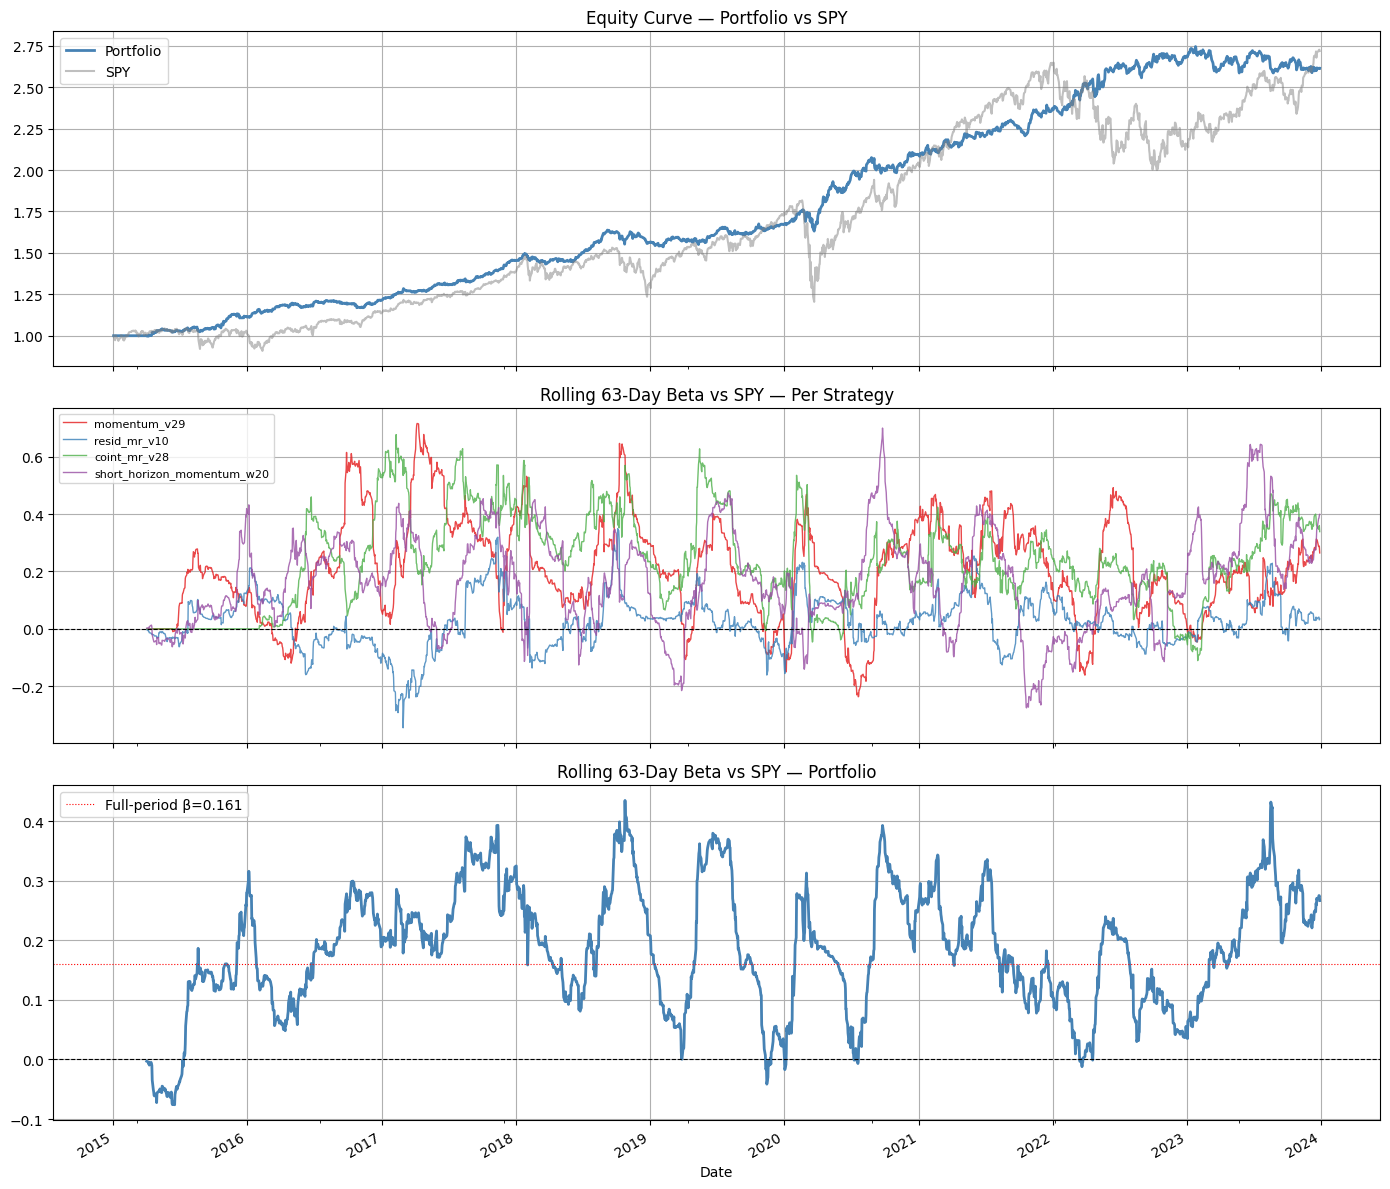

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

port_ret = portfolio._cache["portfolio_returns"]
spy_ret = benchmark.returns["SPY"].reindex(port_ret.index).fillna(0.0)

# --- Full-period beta decomposition by strategy ---
print("--- Beta Decomposition vs SPY ---")
spy_var = spy_ret.var()
rows = []
for study in strategies:
    s_ret = study._cache["portfolio_returns"].reindex(port_ret.index).fillna(0.0)
    beta = s_ret.cov(spy_ret) / spy_var
    corr = s_ret.corr(spy_ret)
    alpha = (s_ret.mean() - beta * spy_ret.mean()) * 252
    rows.append({"strategy": study._name, "beta": beta, "corr": corr, "alpha_ann": alpha})

decomp = pd.DataFrame(rows).set_index("strategy")
print(decomp.round(4).to_string())

port_beta = port_ret.cov(spy_ret) / spy_var
port_alpha = (port_ret.mean() - port_beta * spy_ret.mean()) * 252
print(f"\nPortfolio  beta={port_beta:.4f}  corr={port_ret.corr(spy_ret):.4f}  alpha_ann={port_alpha:.2%}")

# --- Rolling 63-day beta per strategy + portfolio ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Equity curves
(1 + port_ret).cumprod().plot(ax=axes[0], color="steelblue", linewidth=2, label="Portfolio")
(1 + spy_ret).cumprod().plot(ax=axes[0], color="gray", alpha=0.5, label="SPY")
axes[0].set_title("Equity Curve — Portfolio vs SPY")
axes[0].legend()
axes[0].grid(True)

# Rolling beta per strategy
roll_var = spy_ret.rolling(63).var()
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
for study, color in zip(strategies, colors):
    s_ret = study._cache["portfolio_returns"].reindex(port_ret.index).fillna(0.0)
    roll_beta = s_ret.rolling(63).cov(spy_ret) / roll_var
    roll_beta.plot(ax=axes[1], label=study._name, color=color, alpha=0.8, linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Rolling 63-Day Beta vs SPY — Per Strategy")
axes[1].legend(fontsize=8)
axes[1].grid(True)

# Rolling portfolio beta
port_roll_beta = port_ret.rolling(63).cov(spy_ret) / roll_var
port_roll_beta.plot(ax=axes[2], color="steelblue", linewidth=2)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].axhline(port_beta, color="red", linewidth=0.8, linestyle=":", label=f"Full-period β={port_beta:.3f}")
axes[2].set_title("Rolling 63-Day Beta vs SPY — Portfolio")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()